# 02 - LSTM Demand Forecasting

PyTorch LSTM forecasting daily demand 30 days ahead for the shared top-100 / 730-active-day product universe.

**Inputs per window:** 60 days of past quantity + 15 calendar/scaled/engineered feature columns + product embedding.
**Output:** next 30 days of scaled quantity, inverse-scaled per product at evaluation.

**Ensemble handoff:** predictions written to `data/predictions/lstm_test_predictions.csv` with schema `date, item_id, predicted_quantity, actual_quantity` over the shared test window (2024-04-28 -> 2024-09-24, 500 windows, 15,000 rows).

## 0. Environment setup (Colab only)

No-op outside Colab. On Colab: clones the repo, mounts Drive, and symlinks `sales.csv` + `data/processed/` from `MyDrive/demand-forecasting/`. Edit `DRIVE_DATA_DIR` if your Drive layout differs.

In [1]:
# === Colab bootstrap (no-op when running locally) ===
import os, sys, subprocess

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False

if _in_colab():
    REPO_URL = "https://github.com/nhbi05/demand-forecasting.git"
    BRANCH = "feature/lstm-design"
    REPO_DIR = "/content/demand-forecasting"
    # Points at the project folder on Drive (containing sales.csv + data/).
    DRIVE_DATA_DIR = "/content/drive/MyDrive/demand-forecasting"

    if not os.path.exists(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--branch", BRANCH, "--depth", "1", REPO_URL, REPO_DIR],
            check=True,
        )
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=False)

    from google.colab import drive  # noqa: E402
    drive.mount("/content/drive")

    src_csv = os.path.join(DRIVE_DATA_DIR, "sales.csv")
    src_processed = os.path.join(DRIVE_DATA_DIR, "data", "processed")
    dst_csv = os.path.join(REPO_DIR, "sales.csv")
    dst_processed = os.path.join(REPO_DIR, "data", "processed")
    os.makedirs(os.path.join(REPO_DIR, "data"), exist_ok=True)

    for src, dst in [(src_csv, dst_csv), (src_processed, dst_processed)]:
        if not os.path.exists(src):
            raise FileNotFoundError(
                f"Expected {src} on Drive. Upload it (or fix DRIVE_DATA_DIR).")
        if os.path.lexists(dst) and not os.path.samefile(dst, src):
            if os.path.islink(dst) or os.path.isfile(dst):
                os.remove(dst)
        if not os.path.lexists(dst):
            os.symlink(src, dst)

    os.chdir(REPO_DIR)
    print(f"Repo:       {REPO_DIR}")
    print(f"Data root:  {DRIVE_DATA_DIR}")
    print(f"sales.csv:  {os.path.exists(dst_csv)}")
    print(f"processed:  {os.path.exists(dst_processed)}")
else:
    print("Not running in Colab - skipping bootstrap.")

Mounted at /content/drive
Repo:       /content/demand-forecasting
Data root:  /content/drive/MyDrive/demand-forecasting
sales.csv:  True
processed:  True


## 1. Data preparation

Load the canonical shared artifacts produced by `preprocessing.prepare_data()`. Run that once (commented call inside the cell) to regenerate them from `sales.csv` if missing.

In [2]:
import sys, os
# Ensure CWD is the repo root and that the root is on sys.path so `from src
# import ...` works whether launched from notebooks/, repo root, or Colab.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import json
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader

from src import preprocessing
from src.models import lstm_model

torch.manual_seed(42)
np.random.seed(42)

In [ ]:
# Regenerate the shared artifacts only if they're missing.
PROCESSED_DIR = "data/processed"
required = ["daily.csv", "splits.json", "selected_products.json",
            "scalers.pkl", "feature_columns.json"]
needs_regen = any(not (Path(PROCESSED_DIR) / f).exists() for f in required)

if needs_regen:
    print("Regenerating shared preprocessing artifacts...")
    preprocessing.prepare_data(csv_path="sales.csv", outdir=PROCESSED_DIR)
else:
    print("Shared artifacts already present - using them.")

Shared artifacts already present - using them.


In [4]:
# Load the canonical shared artifacts
artifacts = preprocessing.load_artifacts(PROCESSED_DIR)
daily = artifacts["daily"]
splits = artifacts["splits"]
selected_products = artifacts["selected_products"]
scalers = artifacts["scalers"]
feature_columns = artifacts["feature_columns"]
metadata = artifacts.get("metadata", {})

print(f"Products: {len(selected_products)}")
print(f"Daily rows: {len(daily):,}")
print(f"Benchmark: {metadata.get('benchmark_rule', 'n/a')}")
print(f"Splits: {splits}")
print()
print(f"Shared feature columns ({len(feature_columns['shared_default'])}):")
for col in feature_columns['shared_default']:
    print(f"  - {col}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Products: 100
Daily rows: 76,100
Benchmark: top 100 products by positive_quantity with at least 730 active sales days
Splits: {'train_start': '2022-08-28', 'train_end': '2024-02-27', 'val_start': '2024-02-28', 'val_end': '2024-04-27', 'test_start': '2024-04-28', 'test_end': '2024-09-26'}

Shared feature columns (14):
  - dow_sin
  - dow_cos
  - dom_sin
  - dom_cos
  - month_sin
  - month_cos
  - quantity_scaled
  - positive_quantity_scaled
  - returns_quantity_scaled
  - price_base_scaled
  - sum_total_scaled
  - transaction_count_scaled
  - store_count_scaled
  - had_sales


## 2. EDA

Sanity checks: representative products, scaled feature ranges in the training period, and a price/quantity overlay for the top product.

In [ ]:
totals = daily.groupby("item_id")["quantity"].sum().sort_values(ascending=False)
representatives = [
    totals.index[0],          # highest volume
    totals.index[len(totals) // 2],  # median volume
    totals.index[-1],         # lowest of top 100
]
print("Representative products (top, median, bottom of top-100):")
print(representatives)

Representative products (top, median, bottom of top-100):
['b0d24502fb66', '21b8dfbd361a', '6790437682c8']


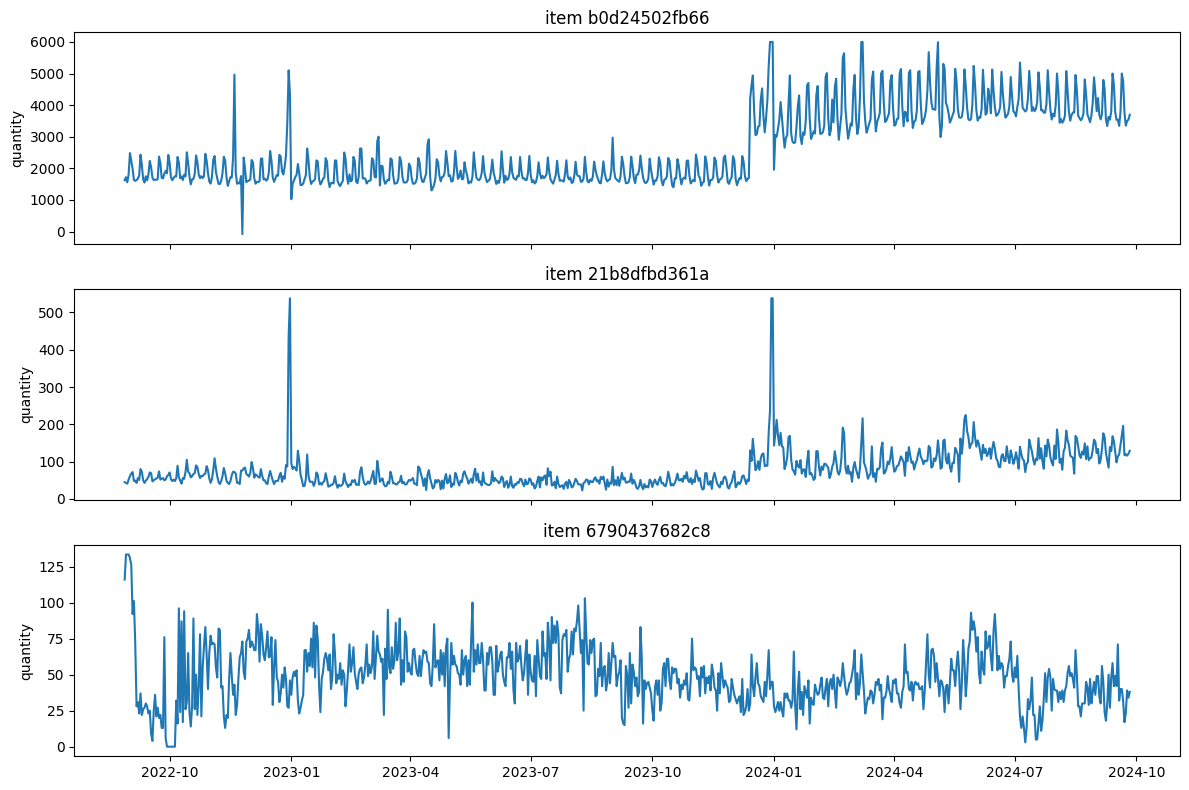

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, item_id in zip(axes, representatives):
    sub = daily[daily["item_id"] == item_id].sort_values("date")
    ax.plot(sub["date"], sub["quantity"])
    ax.set_title(f"item {item_id}")
    ax.set_ylabel("quantity")
plt.tight_layout(); plt.show()

In [7]:
train_end = pd.Timestamp(splits["train_end"])
train_rows = daily[daily["date"] <= train_end]
scaled_cols = feature_columns["scaled"]
print("Scaled feature ranges in training period:")
print(train_rows[scaled_cols].describe().loc[["min", "max", "mean"]].T.round(3))

Scaled feature ranges in training period:
                          min  max   mean
quantity_scaled           0.0  1.0  0.357
positive_quantity_scaled  0.0  1.0  0.357
returns_quantity_scaled   0.0  0.0  0.000
price_base_scaled         0.0  1.0  0.547
sum_total_scaled          0.0  1.0  0.275
transaction_count_scaled  0.0  1.0  0.549
store_count_scaled        0.0  1.0  0.549


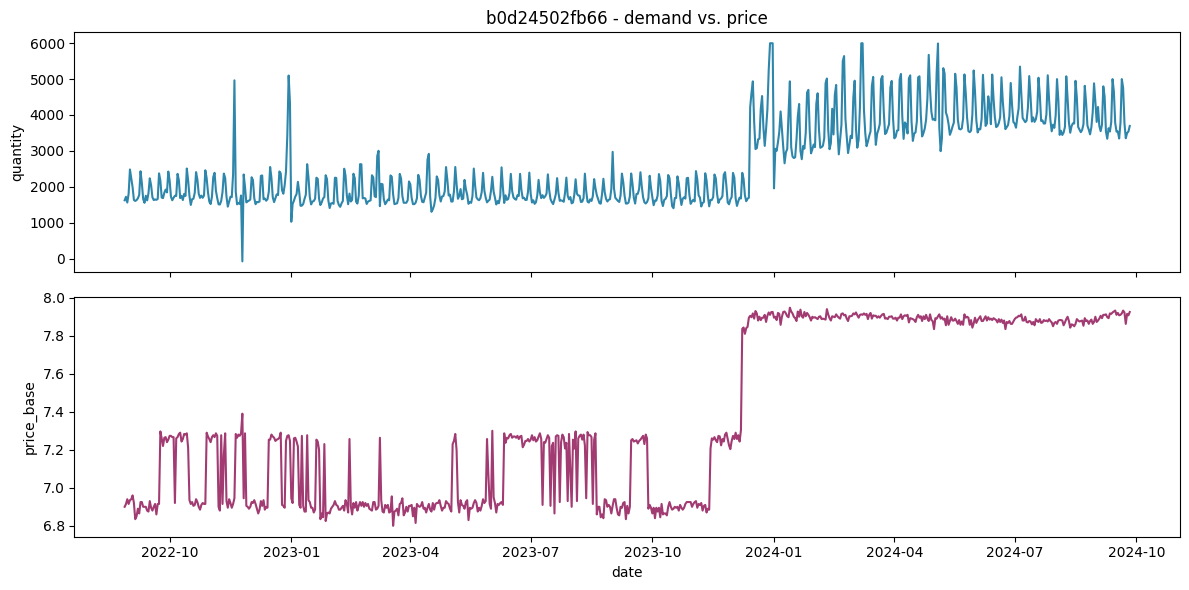

In [8]:
prod = representatives[0]
sub = daily[daily["item_id"] == prod].sort_values("date").set_index("date")
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(sub.index, sub["quantity"], label="demand", color="#2E86AB")
axes[0].set_title(f"{prod} - demand vs. price")
axes[0].set_ylabel("quantity")
axes[1].plot(sub.index, sub["price_base"], label="price", color="#A23B72")
axes[1].set_ylabel("price_base"); axes[1].set_xlabel("date")
plt.tight_layout(); plt.show()

## 3. Feature engineering

Build the 15-feature input sequences (12 from the shared contract minus `returns_quantity_scaled` and `positive_quantity_scaled`, plus 3 engineered: `rolling_7_scaled`, `rolling_30_scaled`, `lag_7_scaled`). All features look backward only - no leakage.

In [9]:
# v4: engineered features for level / trend / weekly-lag signal.
# Compute on the full daily DataFrame per item_id before slicing.
daily = daily.sort_values(["item_id", "date"]).reset_index(drop=True)

g = daily.groupby("item_id", sort=False)["quantity_scaled"]
daily["rolling_7_scaled"]  = g.transform(lambda s: s.rolling(7,  min_periods=1).mean())
daily["rolling_30_scaled"] = g.transform(lambda s: s.rolling(30, min_periods=1).mean())
daily["lag_7_scaled"]      = g.transform(lambda s: s.shift(7))
# First 7 days per product have no lag-7. Fall back to the rolling-7 mean
# (which is defined from day 1 via min_periods=1) so we don't introduce NaNs.
daily["lag_7_scaled"] = daily["lag_7_scaled"].fillna(daily["rolling_7_scaled"])

ENGINEERED_FEATURES = ["rolling_7_scaled", "rolling_30_scaled", "lag_7_scaled"]
print("v4 engineered features (per item_id, computed on quantity_scaled):")
print(daily[ENGINEERED_FEATURES].describe().loc[["min", "max", "mean", "std"]].T.round(4))
print()
print(f"NaNs introduced: {int(daily[ENGINEERED_FEATURES].isna().sum().sum())} (should be 0)")

v4 engineered features (per item_id, computed on quantity_scaled):
                      min  max    mean     std
rolling_7_scaled  -0.0216  1.0  0.4144  0.2241
rolling_30_scaled  0.0000  1.0  0.4105  0.2115
lag_7_scaled      -0.0328  1.0  0.4129  0.2534

NaNs introduced: 0 (should be 0)


In [10]:
LOOKBACK = 60
HORIZON = 30
PERIOD = 7   # weekly seasonality (used for the seasonal-naive baseline only)
BATCH_SIZE = 64

slices = preprocessing.slice_by_split(daily, splits, lookback_days=LOOKBACK)
train_slice, val_slice, test_slice = slices["train"], slices["val"], slices["test"]

product_to_idx = {p: i for i, p in enumerate(sorted(selected_products))}
N_PRODUCTS = len(product_to_idx)

# v4 feature set: shared_default minus the 2 dead/duplicate columns,
# plus the 3 engineered ones. Contract output is unchanged - we just
# choose which subset *this* model consumes as input.
DROPPED_FEATURES = {"returns_quantity_scaled", "positive_quantity_scaled"}
SHARED_FEATURES = [c for c in feature_columns["shared_default"]
                   if c not in DROPPED_FEATURES] + ENGINEERED_FEATURES
N_FEATURES = len(SHARED_FEATURES)

print(f"train slice: {len(train_slice):,} rows ({train_slice['date'].min()} -> {train_slice['date'].max()})")
print(f"val slice:   {len(val_slice):,} rows ({val_slice['date'].min()} -> {val_slice['date'].max()})")
print(f"test slice:  {len(test_slice):,} rows ({test_slice['date'].min()} -> {test_slice['date'].max()})")
print(f"using {N_FEATURES} features: {SHARED_FEATURES}")

train slice: 54,900 rows (2022-08-28 00:00:00 -> 2024-02-27 00:00:00)
val slice:   12,000 rows (2023-12-30 00:00:00 -> 2024-04-27 00:00:00)
test slice:  21,200 rows (2024-02-28 00:00:00 -> 2024-09-26 00:00:00)
using 15 features: ['dow_sin', 'dow_cos', 'dom_sin', 'dom_cos', 'month_sin', 'month_cos', 'quantity_scaled', 'price_base_scaled', 'sum_total_scaled', 'transaction_count_scaled', 'store_count_scaled', 'had_sales', 'rolling_7_scaled', 'rolling_30_scaled', 'lag_7_scaled']


In [11]:
X_qty_tr, X_feat_tr, idx_tr, y_tr = preprocessing.create_sequences(
    train_slice, product_to_idx,
    lookback=LOOKBACK, horizon=HORIZON,
    feature_cols=SHARED_FEATURES,
    target_col="quantity_scaled",
)
X_qty_va, X_feat_va, idx_va, y_va = preprocessing.create_sequences(
    val_slice, product_to_idx,
    lookback=LOOKBACK, horizon=HORIZON,
    feature_cols=SHARED_FEATURES,
    target_col="quantity_scaled",
)
X_qty_te, X_feat_te, idx_te, y_te = preprocessing.create_sequences(
    test_slice, product_to_idx,
    lookback=LOOKBACK, horizon=HORIZON,
    feature_cols=SHARED_FEATURES,
    target_col="quantity_scaled",
)

print(f"train windows: X_qty {X_qty_tr.shape}, X_feat {X_feat_tr.shape}, y {y_tr.shape}")
print(f"val windows:   X_qty {X_qty_va.shape}, X_feat {X_feat_va.shape}, y {y_va.shape}")
print(f"test windows:  X_qty {X_qty_te.shape}, X_feat {X_feat_te.shape}, y {y_te.shape}")

train windows: X_qty (46000, 60, 1), X_feat (46000, 60, 15), y (46000, 30)
val windows:   X_qty (3100, 60, 1), X_feat (3100, 60, 15), y (3100, 30)
test windows:  X_qty (12300, 60, 1), X_feat (12300, 60, 15), y (12300, 30)


In [ ]:
# Quick diagnostic: training target distribution.
print(f"y_scaled target - mean {y_tr.mean():.4f}, std {y_tr.std():.4f}, "
      f"min {y_tr.min():.4f}, max {y_tr.max():.4f}")

y_scaled target - mean 0.3571, std 0.2196, min 0.0000, max 1.0000


In [ ]:
train_ds = lstm_model.LSTMDataset(X_qty_tr, X_feat_tr, idx_tr, y_tr)
val_ds   = lstm_model.LSTMDataset(X_qty_va, X_feat_va, idx_va, y_va)
test_ds  = lstm_model.LSTMDataset(X_qty_te, X_feat_te, idx_te, y_te)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"train batches: {len(train_loader)}")
print(f"val batches:   {len(val_loader)}")
print(f"test batches:  {len(test_loader)}")

train batches: 719
val batches:   49
test batches:  193


## 4. Training

Train `LSTMForecaster` with Huber loss, patience 5, Adam + L2 (`weight_decay=1e-4`). Hyperparameters: hidden 64, layers 2, dropout 0.3, embed 4. Best epoch is auto-selected on val loss; the returned model uses those weights.

In [14]:
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.3
EMBED_DIM = 4
WEIGHT_DECAY = 1e-4
EPOCHS = 100
LR = 1e-3
PATIENCE = 5               # v3: tighter than v2's 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"training on: {DEVICE}")

model = lstm_model.LSTMForecaster(
    n_products=N_PRODUCTS,
    embed_dim=EMBED_DIM,
    lookback=LOOKBACK,
    horizon=HORIZON,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    n_calendar=N_FEATURES,
)
print(model)
n_params = sum(p.numel() for p in model.parameters())
print(f"trainable parameters: {n_params:,}")

training on: cpu
LSTMForecaster(
  (product_embed): Embedding(100, 4)
  (lstm): LSTM(20, 64, num_layers=2, batch_first=True, dropout=0.3)
  (head): Linear(in_features=64, out_features=30, bias=True)
)
trainable parameters: 57,646


In [15]:
trained_model, best_val, best_epoch, history = lstm_model.train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, lr=LR, patience=PATIENCE,
    weight_decay=WEIGHT_DECAY,
    loss_fn=torch.nn.SmoothL1Loss(),   # v3: Huber instead of MSE
    device=DEVICE, verbose=True,
)
print()
print(f"best val Huber loss: {best_val:.6f} at epoch {best_epoch}")

epoch   1 | train 0.0143 | val 0.0178
epoch   2 | train 0.0119 | val 0.0162
epoch   3 | train 0.0113 | val 0.0135
epoch   4 | train 0.0111 | val 0.0142
epoch   5 | train 0.0110 | val 0.0151
epoch   6 | train 0.0110 | val 0.0153
epoch   7 | train 0.0110 | val 0.0152
epoch   8 | train 0.0110 | val 0.0151
epoch   9 | train 0.0109 | val 0.0155
Early stopping at epoch 9 (best was epoch 3 @ val 0.0135).

best val Huber loss: 0.013505 at epoch 3


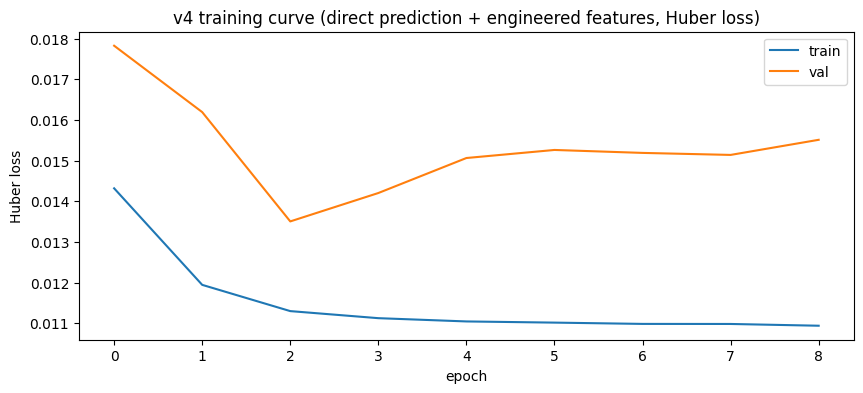

In [16]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history["train_loss"], label="train")
ax.plot(history["val_loss"], label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("Huber loss")
ax.set_title("v4 training curve (direct prediction + engineered features, Huber loss)")
ax.legend(); plt.show()

## 5. Evaluation

500 non-overlapping 30-day test windows (5 per product). Inverse-scale predictions per product, clip at 0, compare against naive and seasonal-naive baselines.

In [17]:
test_start = pd.Timestamp(splits["test_start"])
test_end = pd.Timestamp(splits["test_end"])

eval_rows = []
for item_id, idx in product_to_idx.items():
    series = daily[daily["item_id"] == item_id].sort_values("date").reset_index(drop=True)
    test_first_idx_arr = series.index[series["date"] == test_start]
    if len(test_first_idx_arr) == 0:
        continue
    test_first_idx = test_first_idx_arr[0]
    for w in range(5):
        target_start = test_first_idx + w * HORIZON
        target_end = target_start + HORIZON
        if target_end > len(series):
            break
        input_start = target_start - LOOKBACK
        if input_start < 0:
            break
        eval_rows.append({
            "item_id": item_id,
            "prod_idx": idx,
            "X_qty": series.loc[input_start:target_start - 1, "quantity_scaled"].values.reshape(-1, 1),
            "X_feat": series.loc[input_start:target_start - 1, SHARED_FEATURES].values,
            "y_scaled": series.loc[target_start:target_end - 1, "quantity_scaled"].values,
            "y_real": series.loc[target_start:target_end - 1, "quantity"].values,
            "target_dates": series.loc[target_start:target_end - 1, "date"].values,
        })
print(f"total eval windows: {len(eval_rows)}")

total eval windows: 500


In [18]:
X_qty_eval = np.stack([r["X_qty"]    for r in eval_rows]).astype(np.float32)
X_feat_eval = np.stack([r["X_feat"]    for r in eval_rows]).astype(np.float32)
idx_eval   = np.array([r["prod_idx"] for r in eval_rows], dtype=np.int64)
y_eval_scaled = np.stack([r["y_scaled"] for r in eval_rows]).astype(np.float32)
y_eval_real   = np.stack([r["y_real"]   for r in eval_rows]).astype(np.float32)
item_ids_eval = np.array([r["item_id"] for r in eval_rows])

eval_ds_for_model = lstm_model.LSTMDataset(X_qty_eval, X_feat_eval, idx_eval, y_eval_scaled)
eval_loader = DataLoader(eval_ds_for_model, batch_size=BATCH_SIZE, shuffle=False)
preds_scaled = lstm_model.predict(trained_model, eval_loader, device=DEVICE)

preds_real = lstm_model.inverse_scale_predictions(preds_scaled, item_ids_eval, scalers)
preds_real = np.clip(preds_real, 0.0, None)

print(f"preds_real shape: {preds_real.shape}")

preds_real shape: (500, 30)


In [19]:
m_lstm = lstm_model.compute_metrics(preds_real, y_eval_real)

past_real = np.zeros_like(X_qty_eval[:, :, 0])
for i, item_id in enumerate(item_ids_eval):
    past_real[i] = scalers[item_id].inverse_transform(
        X_qty_eval[i, :, 0].reshape(-1, 1)
    ).flatten()

naive    = lstm_model.naive_baseline(past_real, HORIZON)
seasonal = lstm_model.seasonal_naive_baseline(past_real, HORIZON, period=PERIOD)

m_naive = lstm_model.compute_metrics(naive, y_eval_real)
m_seas  = lstm_model.compute_metrics(seasonal, y_eval_real)

print(f"{'Model':<20} {'RMSE':>10} {'MAE':>10} {'MAPE':>10}")
print("-" * 55)
print(f"{'Naive':<20} {m_naive['rmse']:>10.2f} {m_naive['mae']:>10.2f} {m_naive['mape']:>9.2f}%")
print(f"{'Seasonal-naive':<20} {m_seas['rmse']:>10.2f} {m_seas['mae']:>10.2f} {m_seas['mape']:>9.2f}%")
print(f"{'LSTM v4':<20} {m_lstm['rmse']:>10.2f} {m_lstm['mae']:>10.2f} {m_lstm['mape']:>9.2f}%")
print()
print("Historical reference points (different setups, NOT apples-to-apples):")
print(f"{'  LSTM v1 (top-50)':<20} {97.97:>10.2f} {47.10:>10.2f} {24.08:>9.2f}%")
print(f"{'  LSTM v2 (residual)':<20} {167.63:>10.2f} {50.24:>10.2f} {34.59:>9.2f}%")
print(f"{'  LSTM v3 (12 feat)':<20} {63.70:>10.2f} {33.33:>10.2f} {34.25:>9.2f}%")

Model                      RMSE        MAE       MAPE
-------------------------------------------------------
Naive                    122.94      44.67     41.89%
Seasonal-naive            54.73      29.06     35.09%
LSTM v4                   61.76      31.38     32.89%

Historical reference points (different setups, NOT apples-to-apples):
  LSTM v1 (top-50)        97.97      47.10     24.08%
  LSTM v2 (residual)     167.63      50.24     34.59%
  LSTM v3 (12 feat)       63.70      33.33     34.25%


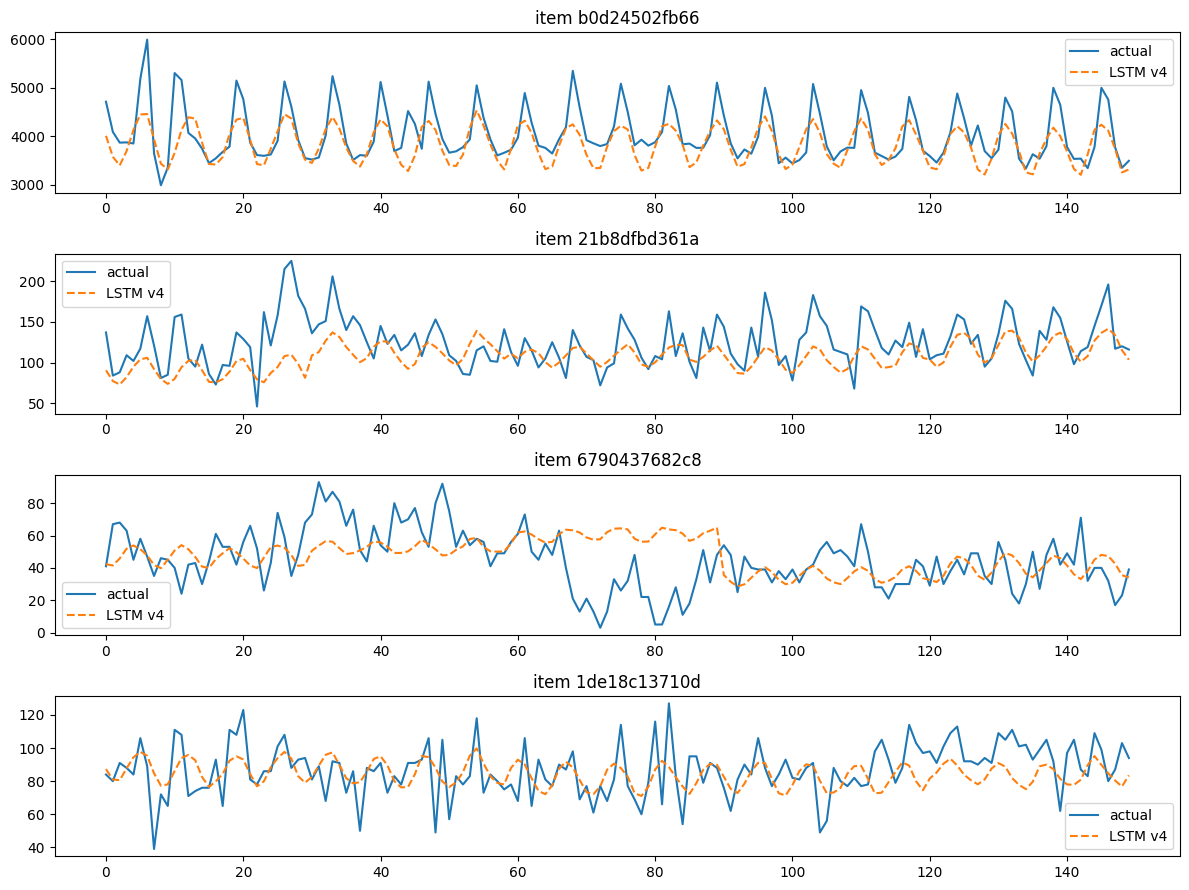

In [20]:
plot_items = list(representatives) + [list(product_to_idx)[10]]
fig, axes = plt.subplots(len(plot_items), 1, figsize=(12, 9), sharex=False)
for ax, item_id in zip(axes, plot_items):
    mask = item_ids_eval == item_id
    actuals = np.concatenate([r["y_real"] for r in eval_rows if r["item_id"] == item_id])
    preds   = np.concatenate(preds_real[mask])
    ax.plot(actuals, label="actual")
    ax.plot(preds, label="LSTM v4", linestyle="--")
    ax.set_title(f"item {item_id}")
    ax.legend()
plt.tight_layout(); plt.show()

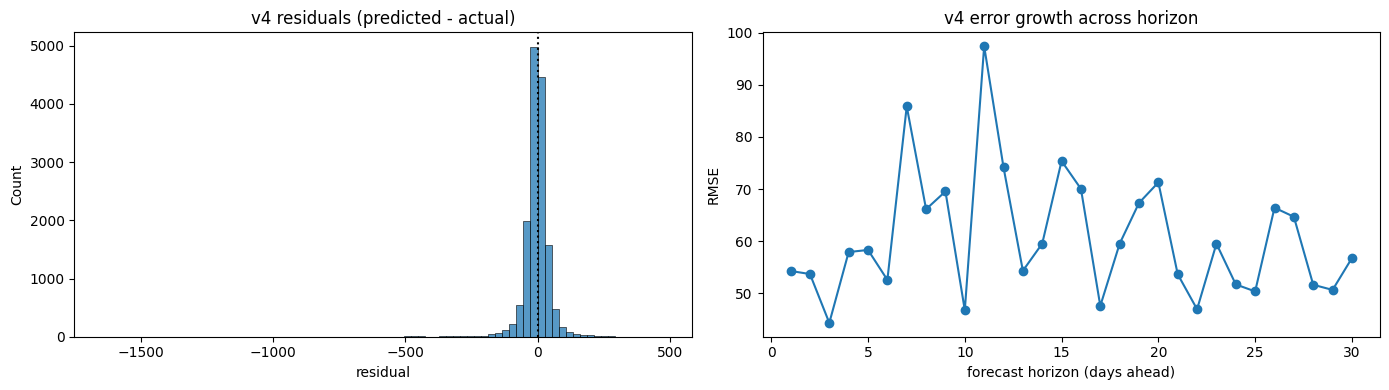

residual mean: -7.175 (~ 0 = unbiased)


In [21]:
residuals_real = (preds_real - y_eval_real).flatten()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(residuals_real, bins=80, ax=axes[0])
axes[0].set_title("v4 residuals (predicted - actual)")
axes[0].axvline(0, color="black", linestyle=":")
axes[0].set_xlabel("residual")

per_day_rmse = np.sqrt(((preds_real - y_eval_real) ** 2).mean(axis=0))
axes[1].plot(np.arange(1, HORIZON + 1), per_day_rmse, marker="o")
axes[1].set_xlabel("forecast horizon (days ahead)")
axes[1].set_ylabel("RMSE")
axes[1].set_title("v4 error growth across horizon")

plt.tight_layout(); plt.show()
print(f"residual mean: {residuals_real.mean():.3f} (~ 0 = unbiased)")

In [22]:
Path("data/predictions").mkdir(parents=True, exist_ok=True)

records = []
for r, p in zip(eval_rows, preds_real):
    for d_idx in range(HORIZON):
        records.append({
            "date": pd.Timestamp(r["target_dates"][d_idx]),
            "item_id": r["item_id"],
            "predicted_quantity": float(p[d_idx]),
            "actual_quantity": float(r["y_real"][d_idx]),
        })
predictions_df = pd.DataFrame(records)
out_path = "data/predictions/lstm_test_predictions.csv"
predictions_df.to_csv(out_path, index=False)
print(f"saved {len(predictions_df):,} rows to {out_path}")
print(f"products: {predictions_df['item_id'].nunique()}, "
      f"date range: {predictions_df['date'].min().date()} -> {predictions_df['date'].max().date()}")

saved 15,000 rows to data/predictions/lstm_test_predictions.csv
products: 100, date range: 2024-04-28 -> 2024-09-24


## 6. Save artifacts

Write `models/lstm_final.pt` and `models/lstm_config.json` (full feature set + hyperparameters + best epoch + final metrics).

In [23]:
Path("models").mkdir(exist_ok=True)
torch.save(trained_model.state_dict(), "models/lstm_final.pt")
with open("models/lstm_config.json", "w") as f:
    json.dump({
        "version": "v4",
        "n_products": N_PRODUCTS,
        "embed_dim": EMBED_DIM,
        "lookback": LOOKBACK,
        "horizon": HORIZON,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "dropout": DROPOUT,
        "weight_decay": WEIGHT_DECAY,
        "n_calendar": N_FEATURES,
        "feature_cols": SHARED_FEATURES,
        "dropped_from_shared_default": sorted(DROPPED_FEATURES),
        "engineered_features": ENGINEERED_FEATURES,
        "target_mode": "direct_scaled_quantity",
        "loss": "SmoothL1Loss",
        "patience": PATIENCE,
        "best_epoch": int(best_epoch),
        "test_metrics": m_lstm,
        "baselines": {"naive": m_naive, "seasonal_naive": m_seas},
    }, f, indent=2)
print("saved models/lstm_final.pt and models/lstm_config.json")

saved models/lstm_final.pt and models/lstm_config.json
